<p align="center" style="font-size:24px;"><b>HW 6 - APS failure at Scania trucks</b></p>


## 1. Tree-Based Methods

Import packages

In [84]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    accuracy_score, classification_report
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.utils import resample
from sklearn.svm import SVC

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

### (a) Download the APS Failure data

In [65]:
train_path = "../data/aps+failure+at+scania+trucks/aps_failure_training_set.csv"
test_path = "../data/aps+failure+at+scania+trucks/aps_failure_test_set.csv"

# skip the first 20 lines(data description lines)
train_df = pd.read_csv(train_path, skiprows=20, na_values='na')
test_df = pd.read_csv(test_path, skiprows=20, na_values='na')

print("Training set preview:")
display(train_df.head())

print("\nTest set preview:")
display(test_df.head())

Training set preview:


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0



Test set preview:


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,60,0.0,20.0,12.0,0.0,0.0,0.0,0.0,0.0,...,1098.0,138.0,412.0,654.0,78.0,88.0,0.0,0.0,0.0,0.0
1,neg,82,0.0,68.0,40.0,0.0,0.0,0.0,0.0,0.0,...,1068.0,276.0,1620.0,116.0,86.0,462.0,0.0,0.0,0.0,0.0
2,neg,66002,2.0,212.0,112.0,0.0,0.0,0.0,0.0,0.0,...,495076.0,380368.0,440134.0,269556.0,1315022.0,153680.0,516.0,0.0,0.0,0.0
3,neg,59816,NaN,1010.0,936.0,0.0,0.0,0.0,0.0,0.0,...,540820.0,243270.0,483302.0,485332.0,431376.0,210074.0,281662.0,3232.0,0.0,0.0
4,neg,1814,NaN,156.0,140.0,0.0,0.0,0.0,0.0,0.0,...,7646.0,4144.0,18466.0,49782.0,3176.0,482.0,76.0,0.0,0.0,0.0


### (b) Data Preparation

#### (i) Research what types of techniques are usually used

These are imputation techniques that are usually used for dealing with data with missing values:

1. mean/median imputation
2. mode imputation
3. k-Nearest Neibors imputation
4. multiple imputation

In this problem, I choose **median imputation** to fill in missing data.

In [66]:
X_train = train_df.drop('class', axis=1)
y_train = train_df['class']
X_test = test_df.drop('class', axis=1)
y_test = test_df['class']

imputer = SimpleImputer(strategy='median')

# fit only on training data (to avoid data leakage)
imputer.fit(X_train)

# transform both train and test data
X_train_imputed = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

#### (ii) Calculate the coefficient of variation

In [67]:
X_train_means = X_train_imputed.mean()
X_train_stds = X_train_imputed.std()

X_train_cv = X_train_stds / X_train_means

X_train_cv_df = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Mean': X_train_means.values,
    'Std': X_train_stds.values,
    'CV': X_train_cv.values
})

print("Train CV preview:")
X_train_cv_df.head()

Train CV preview:


,Feature,Mean,Std,CV
0,aa_000,5.933650e+04,1.454301e+05,2.450938
1,ab_000,1.625000e-01,1.687318e+00,10.383494
2,ac_000,3.362258e+08,7.767625e+08,2.310241
3,ad_000,1.434383e+05,3.504525e+07,244.322816
4,ae_000,6.535000e+00,1.581479e+02,24.200137


In [68]:
X_test_means = X_test_imputed.mean()
X_test_stds = X_test_imputed.std()

X_test_cv = X_test_stds / X_test_means

X_test_cv_df = pd.DataFrame({
    'Feature': X_test_imputed.columns,
    'Mean': X_test_means.values,
    'Std': X_test_stds.values,
    'CV': X_test_cv.values
})

print("Test CV preview:")
X_test_cv_df.head()

Test CV preview:


,Feature,Mean,Std,CV
0,aa_000,6.799698e+04,5.035350e+05,7.405254
1,ab_000,1.755000e-01,1.276049e+00,7.270936
2,ac_000,3.373178e+08,7.778039e+08,2.305849
3,ad_000,3.614964e+02,1.351353e+03,3.738220
4,ae_000,6.151125e+00,1.156172e+02,18.796107


#### (iii) Plot a correlation matrix

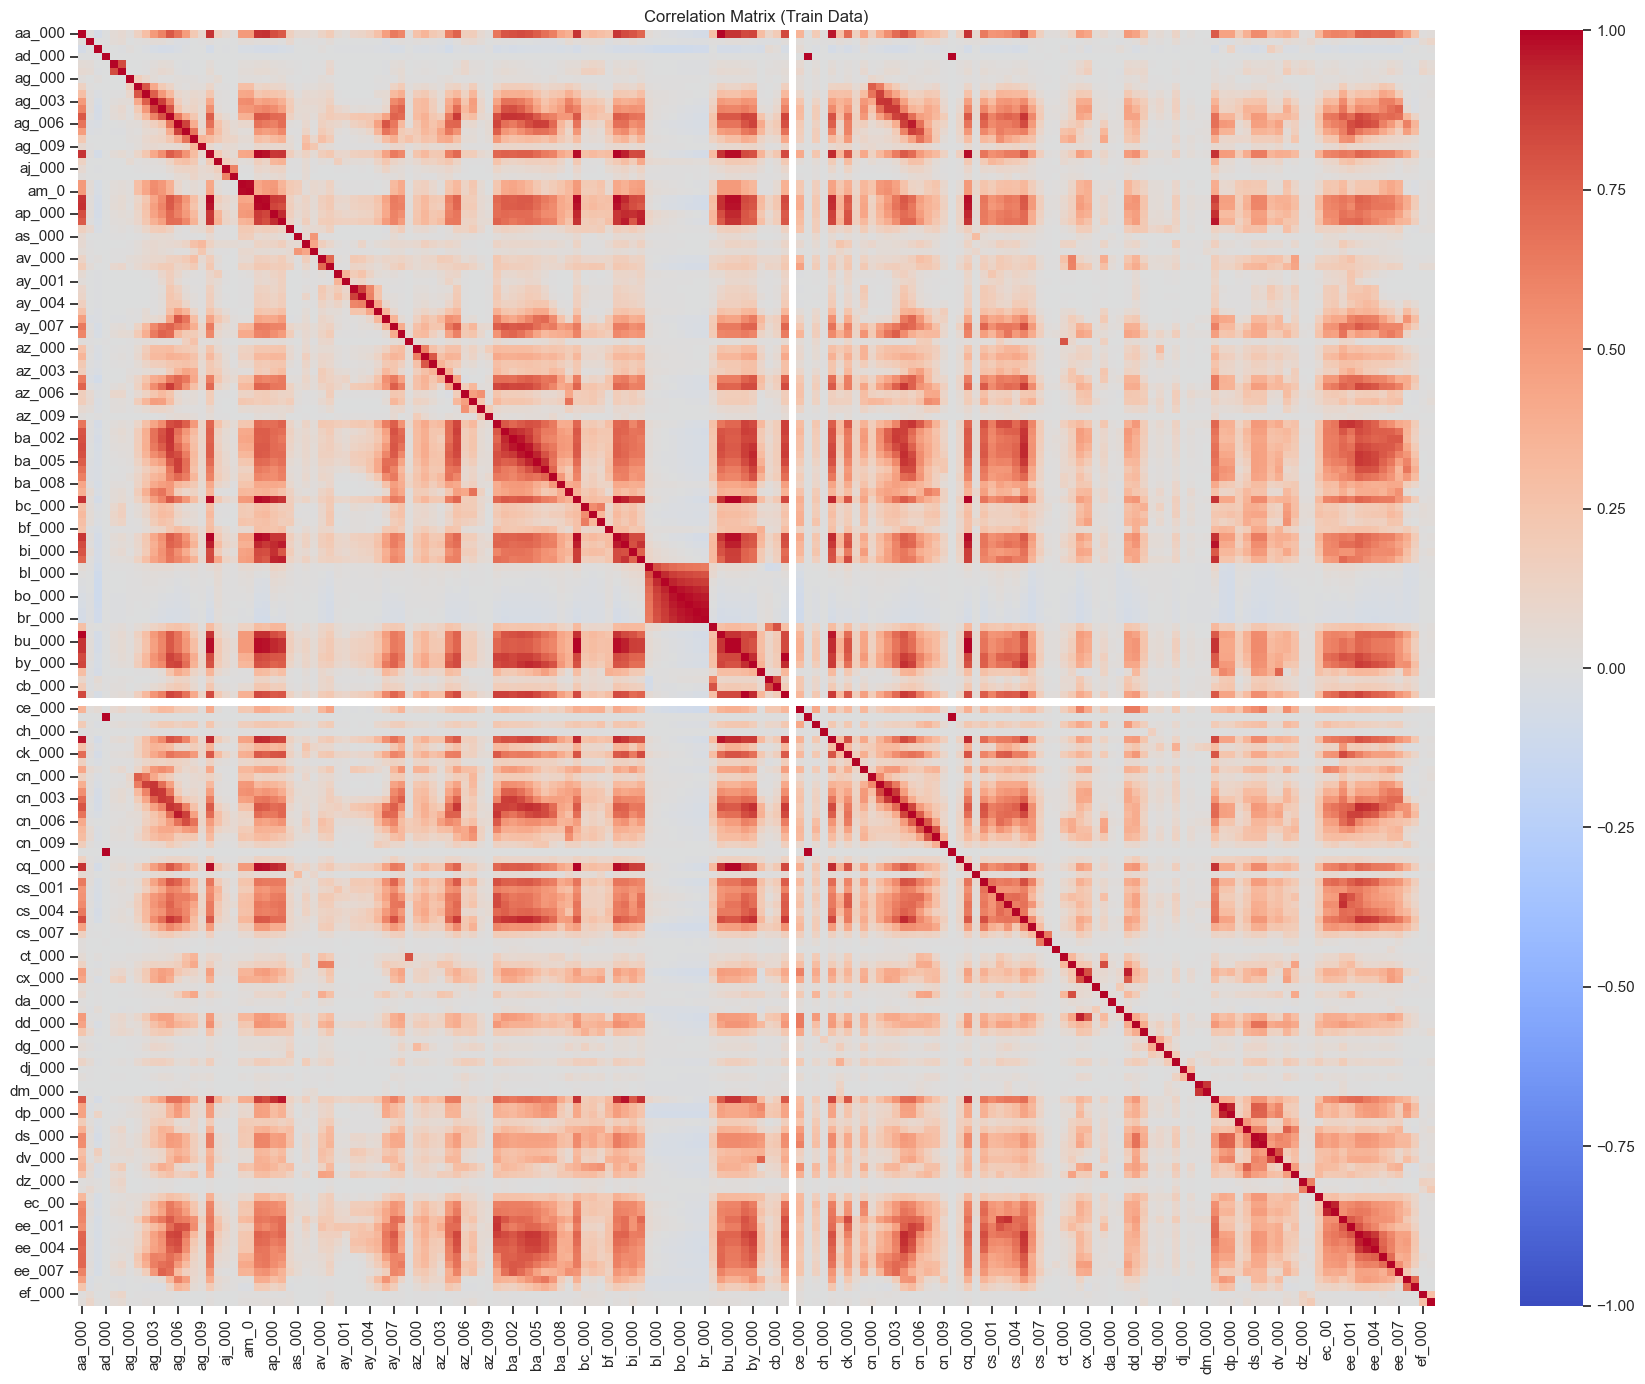

In [69]:
corr_train = X_train_imputed.corr(method='pearson')


plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_train, cmap="coolwarm", vmin=-1, vmax=1
)
plt.title("Correlation Matrix (Train Data)")
plt.tight_layout()
plt.show()

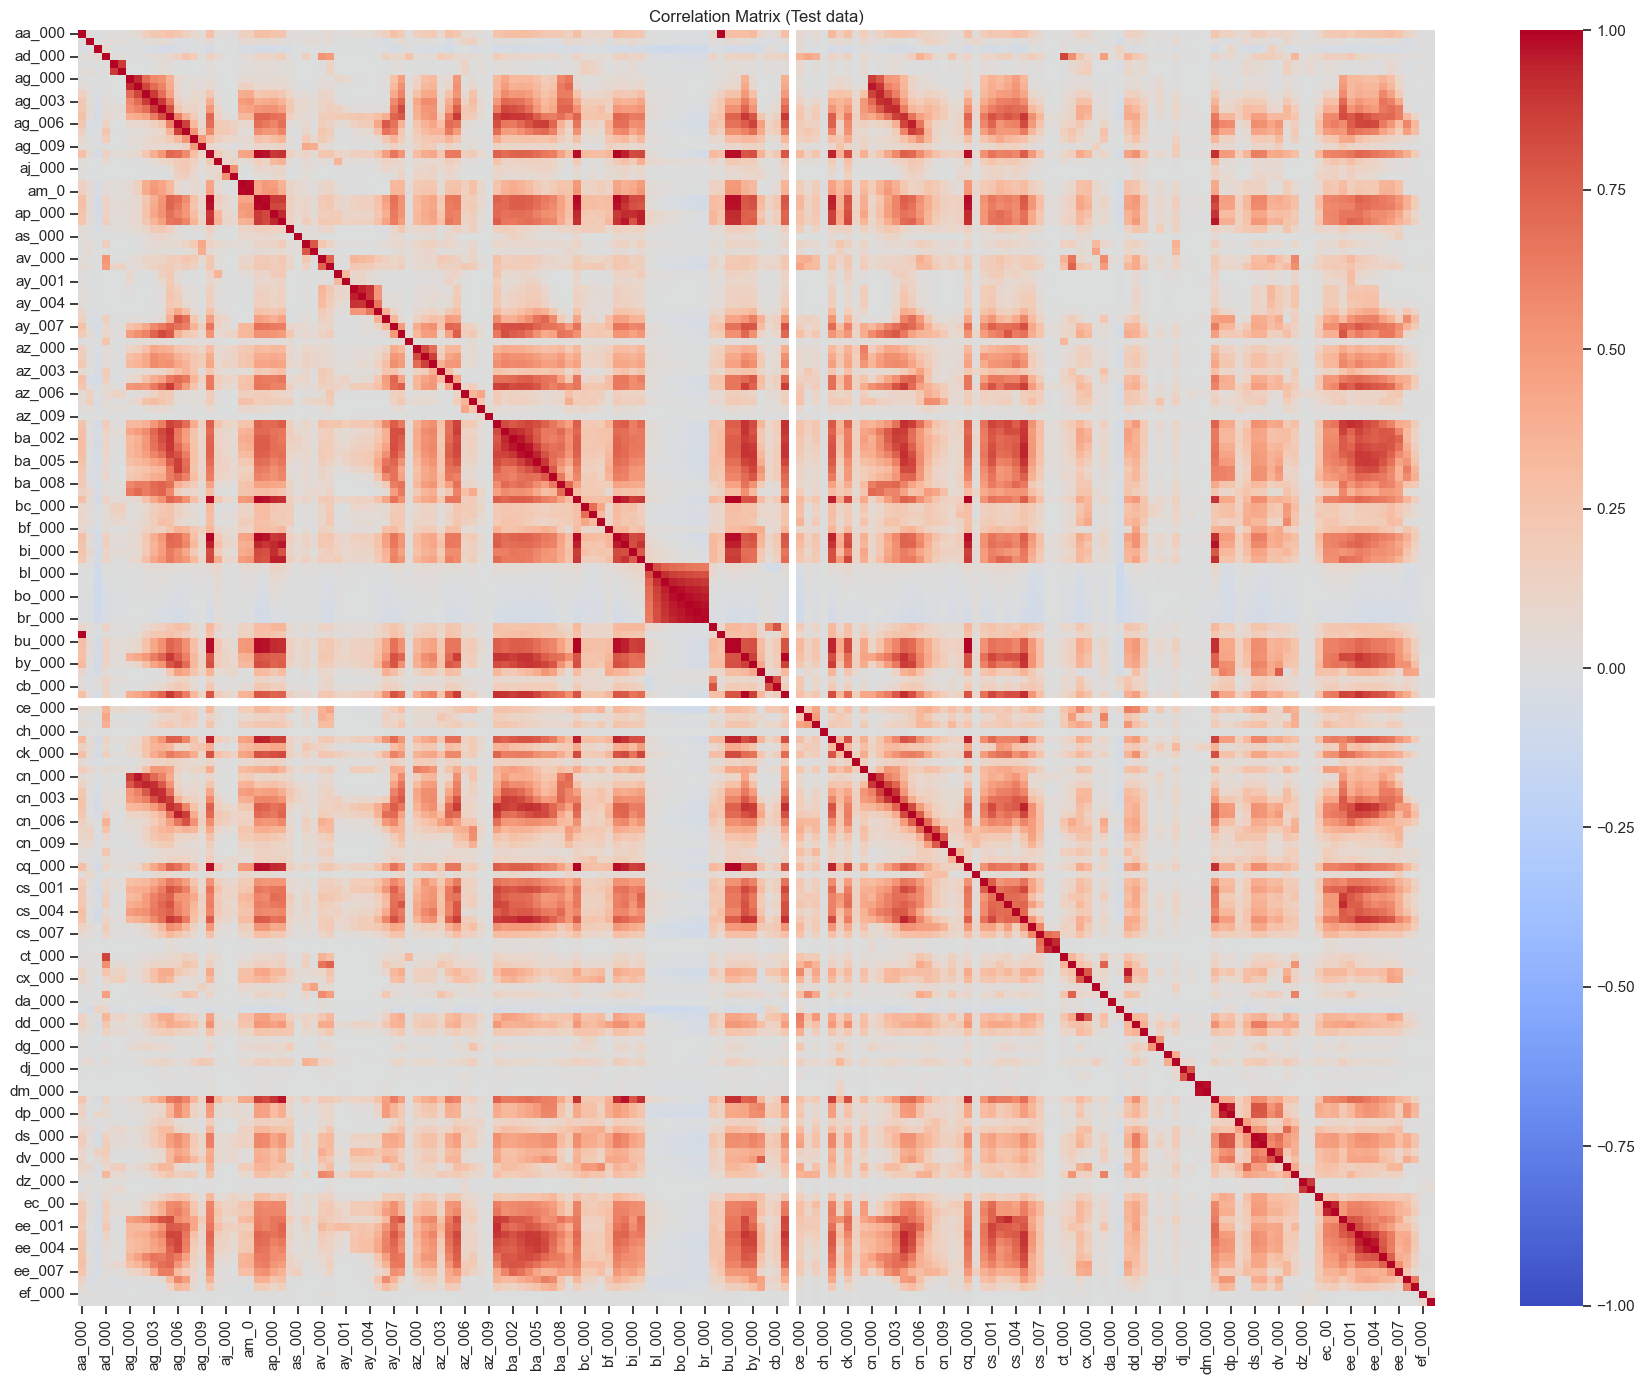

In [70]:
corr_test  = X_test_imputed.corr(method='pearson')

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_test, cmap="coolwarm", vmin=-1, vmax=1
)
plt.title("Correlation Matrix (Test data)")
plt.tight_layout()
plt.show()

#### (iv) Make scatter plots and box plots

- Step 1: sort features by CV
- Step 2: pick ⌊√170⌋ = 13 features with highest CV
- Step 3: draw pairplots for train data and test data separately

Top 13 train features by CV:
 ['cf_000', 'co_000', 'ad_000', 'cs_009', 'dh_000', 'dj_000', 'ag_000', 'as_000', 'ay_009', 'ak_000', 'az_009', 'ch_000', 'au_000']

Top 13 test features by CV:
 ['cs_009', 'ak_000', 'au_000', 'as_000', 'df_000', 'ch_000', 'cs_008', 'eg_000', 'az_009', 'dj_000', 'ag_000', 'ef_000', 'dk_000']


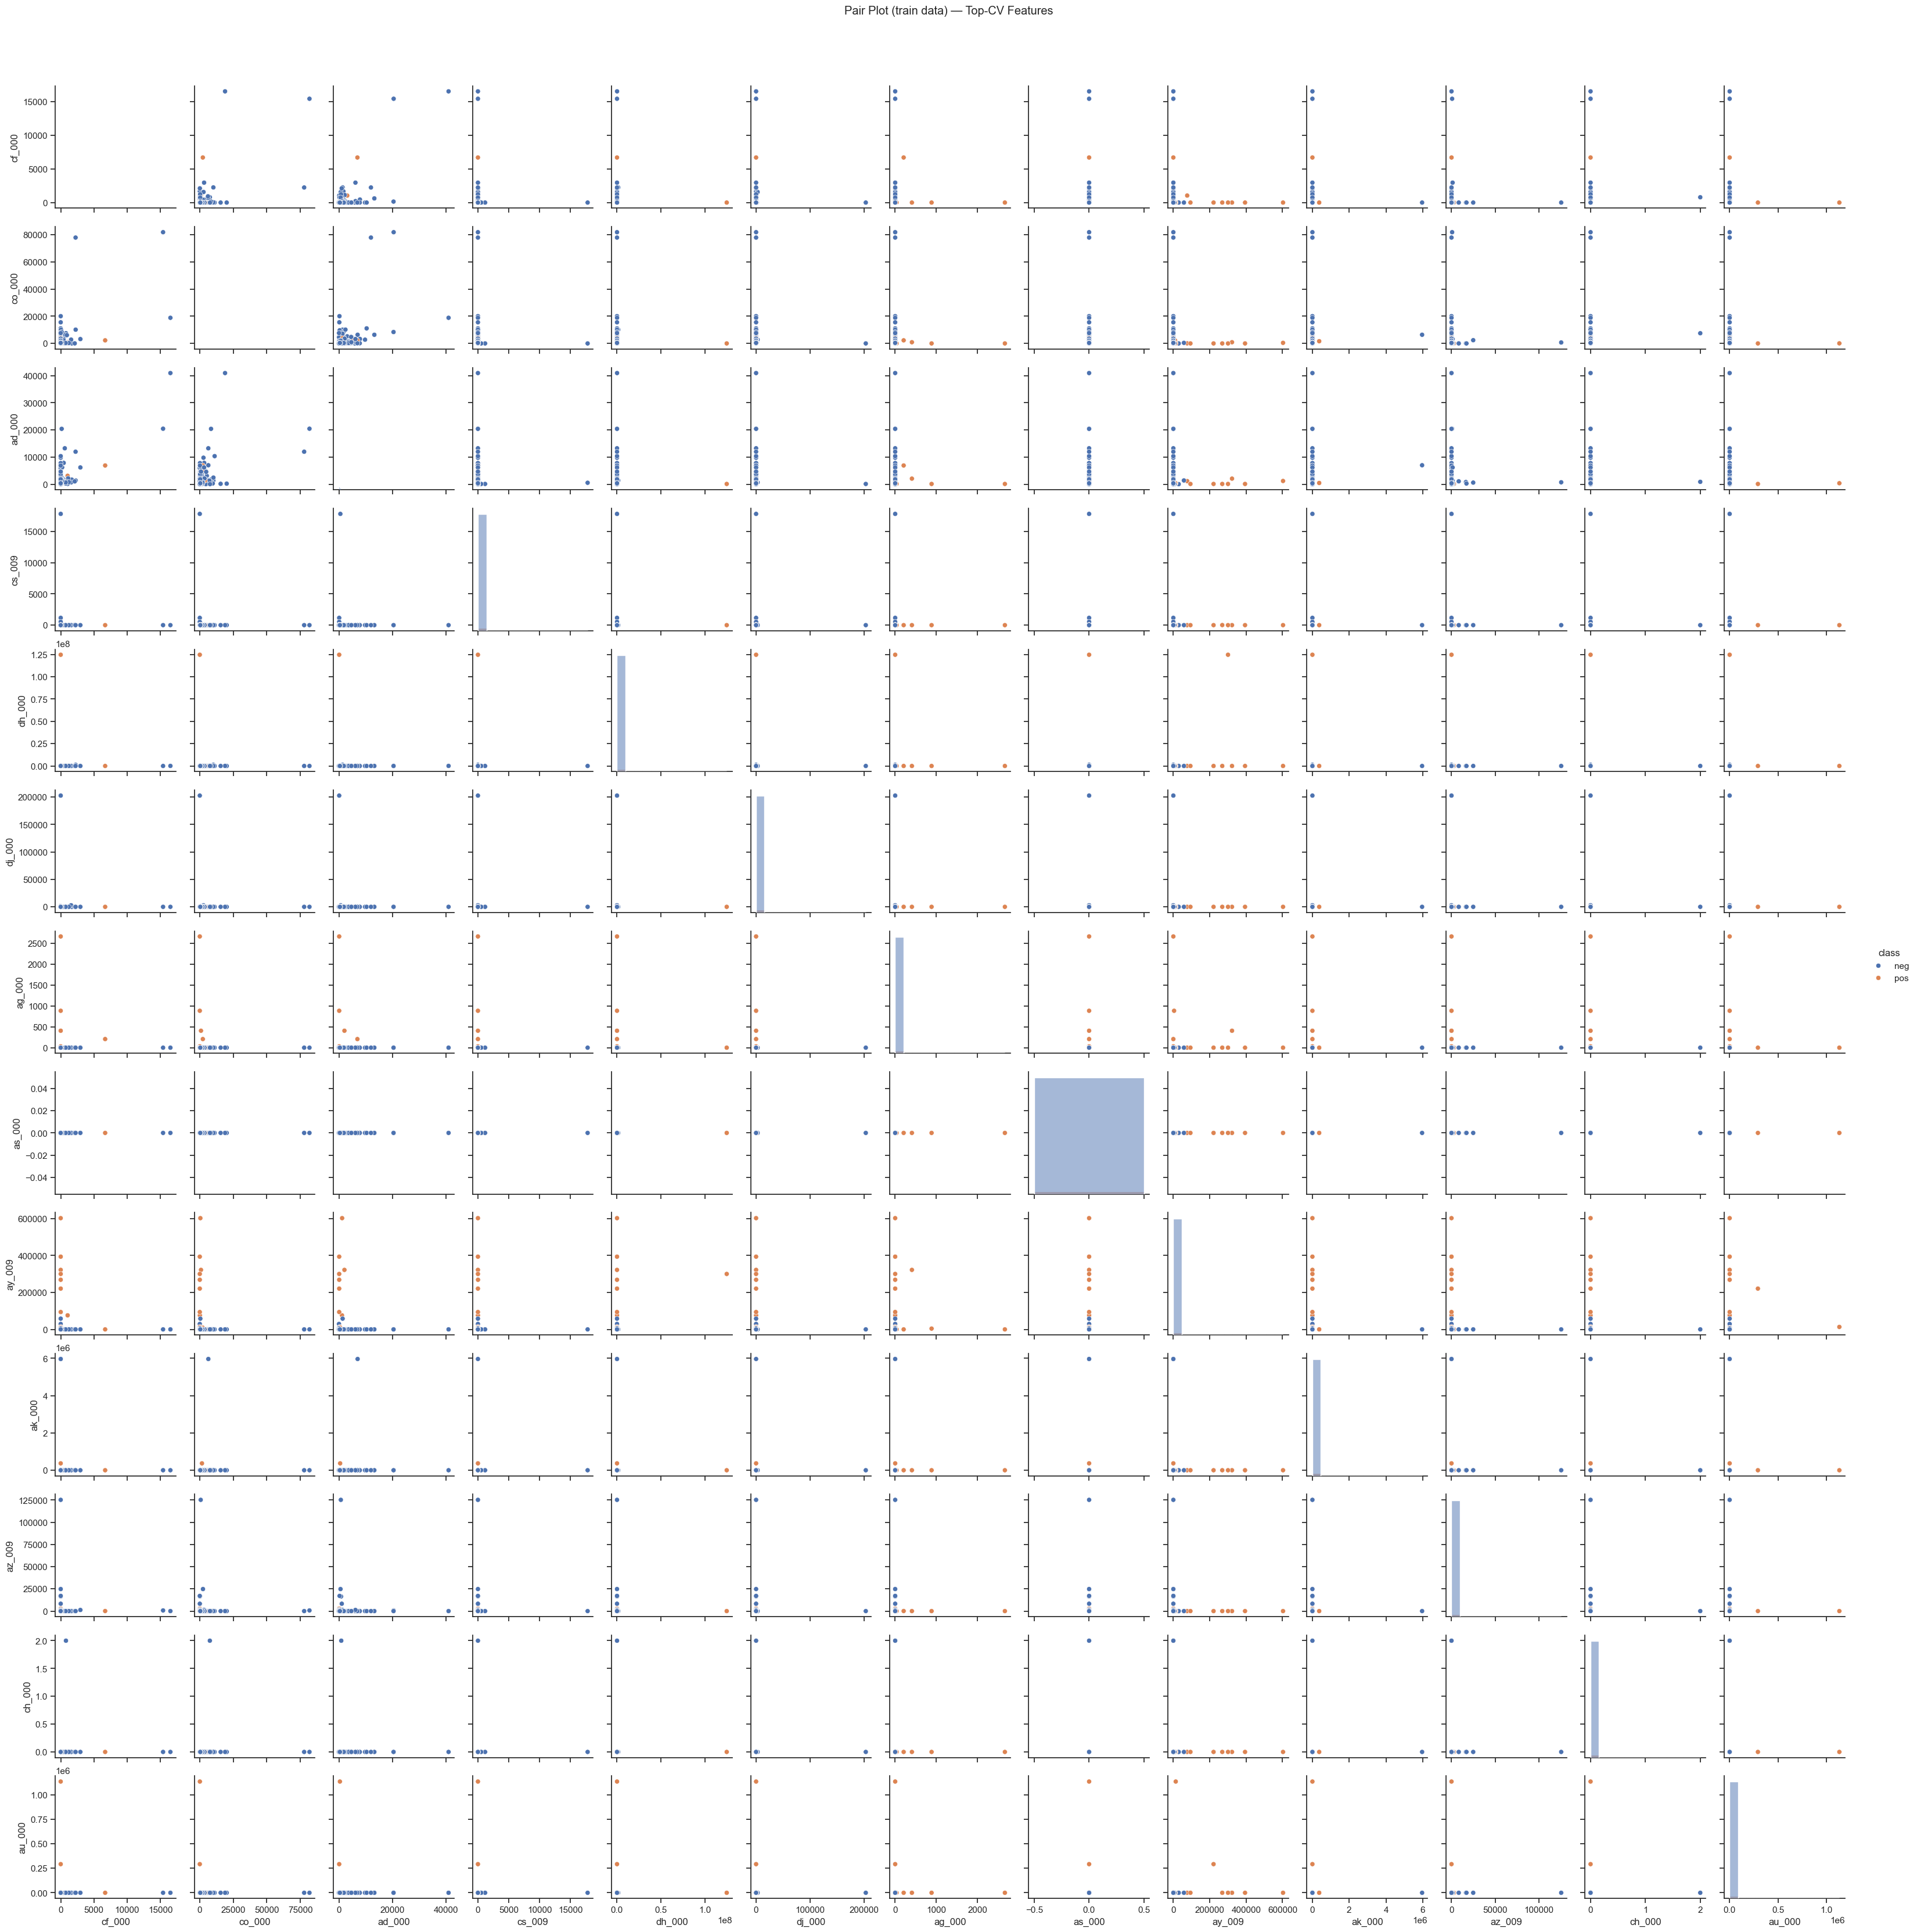

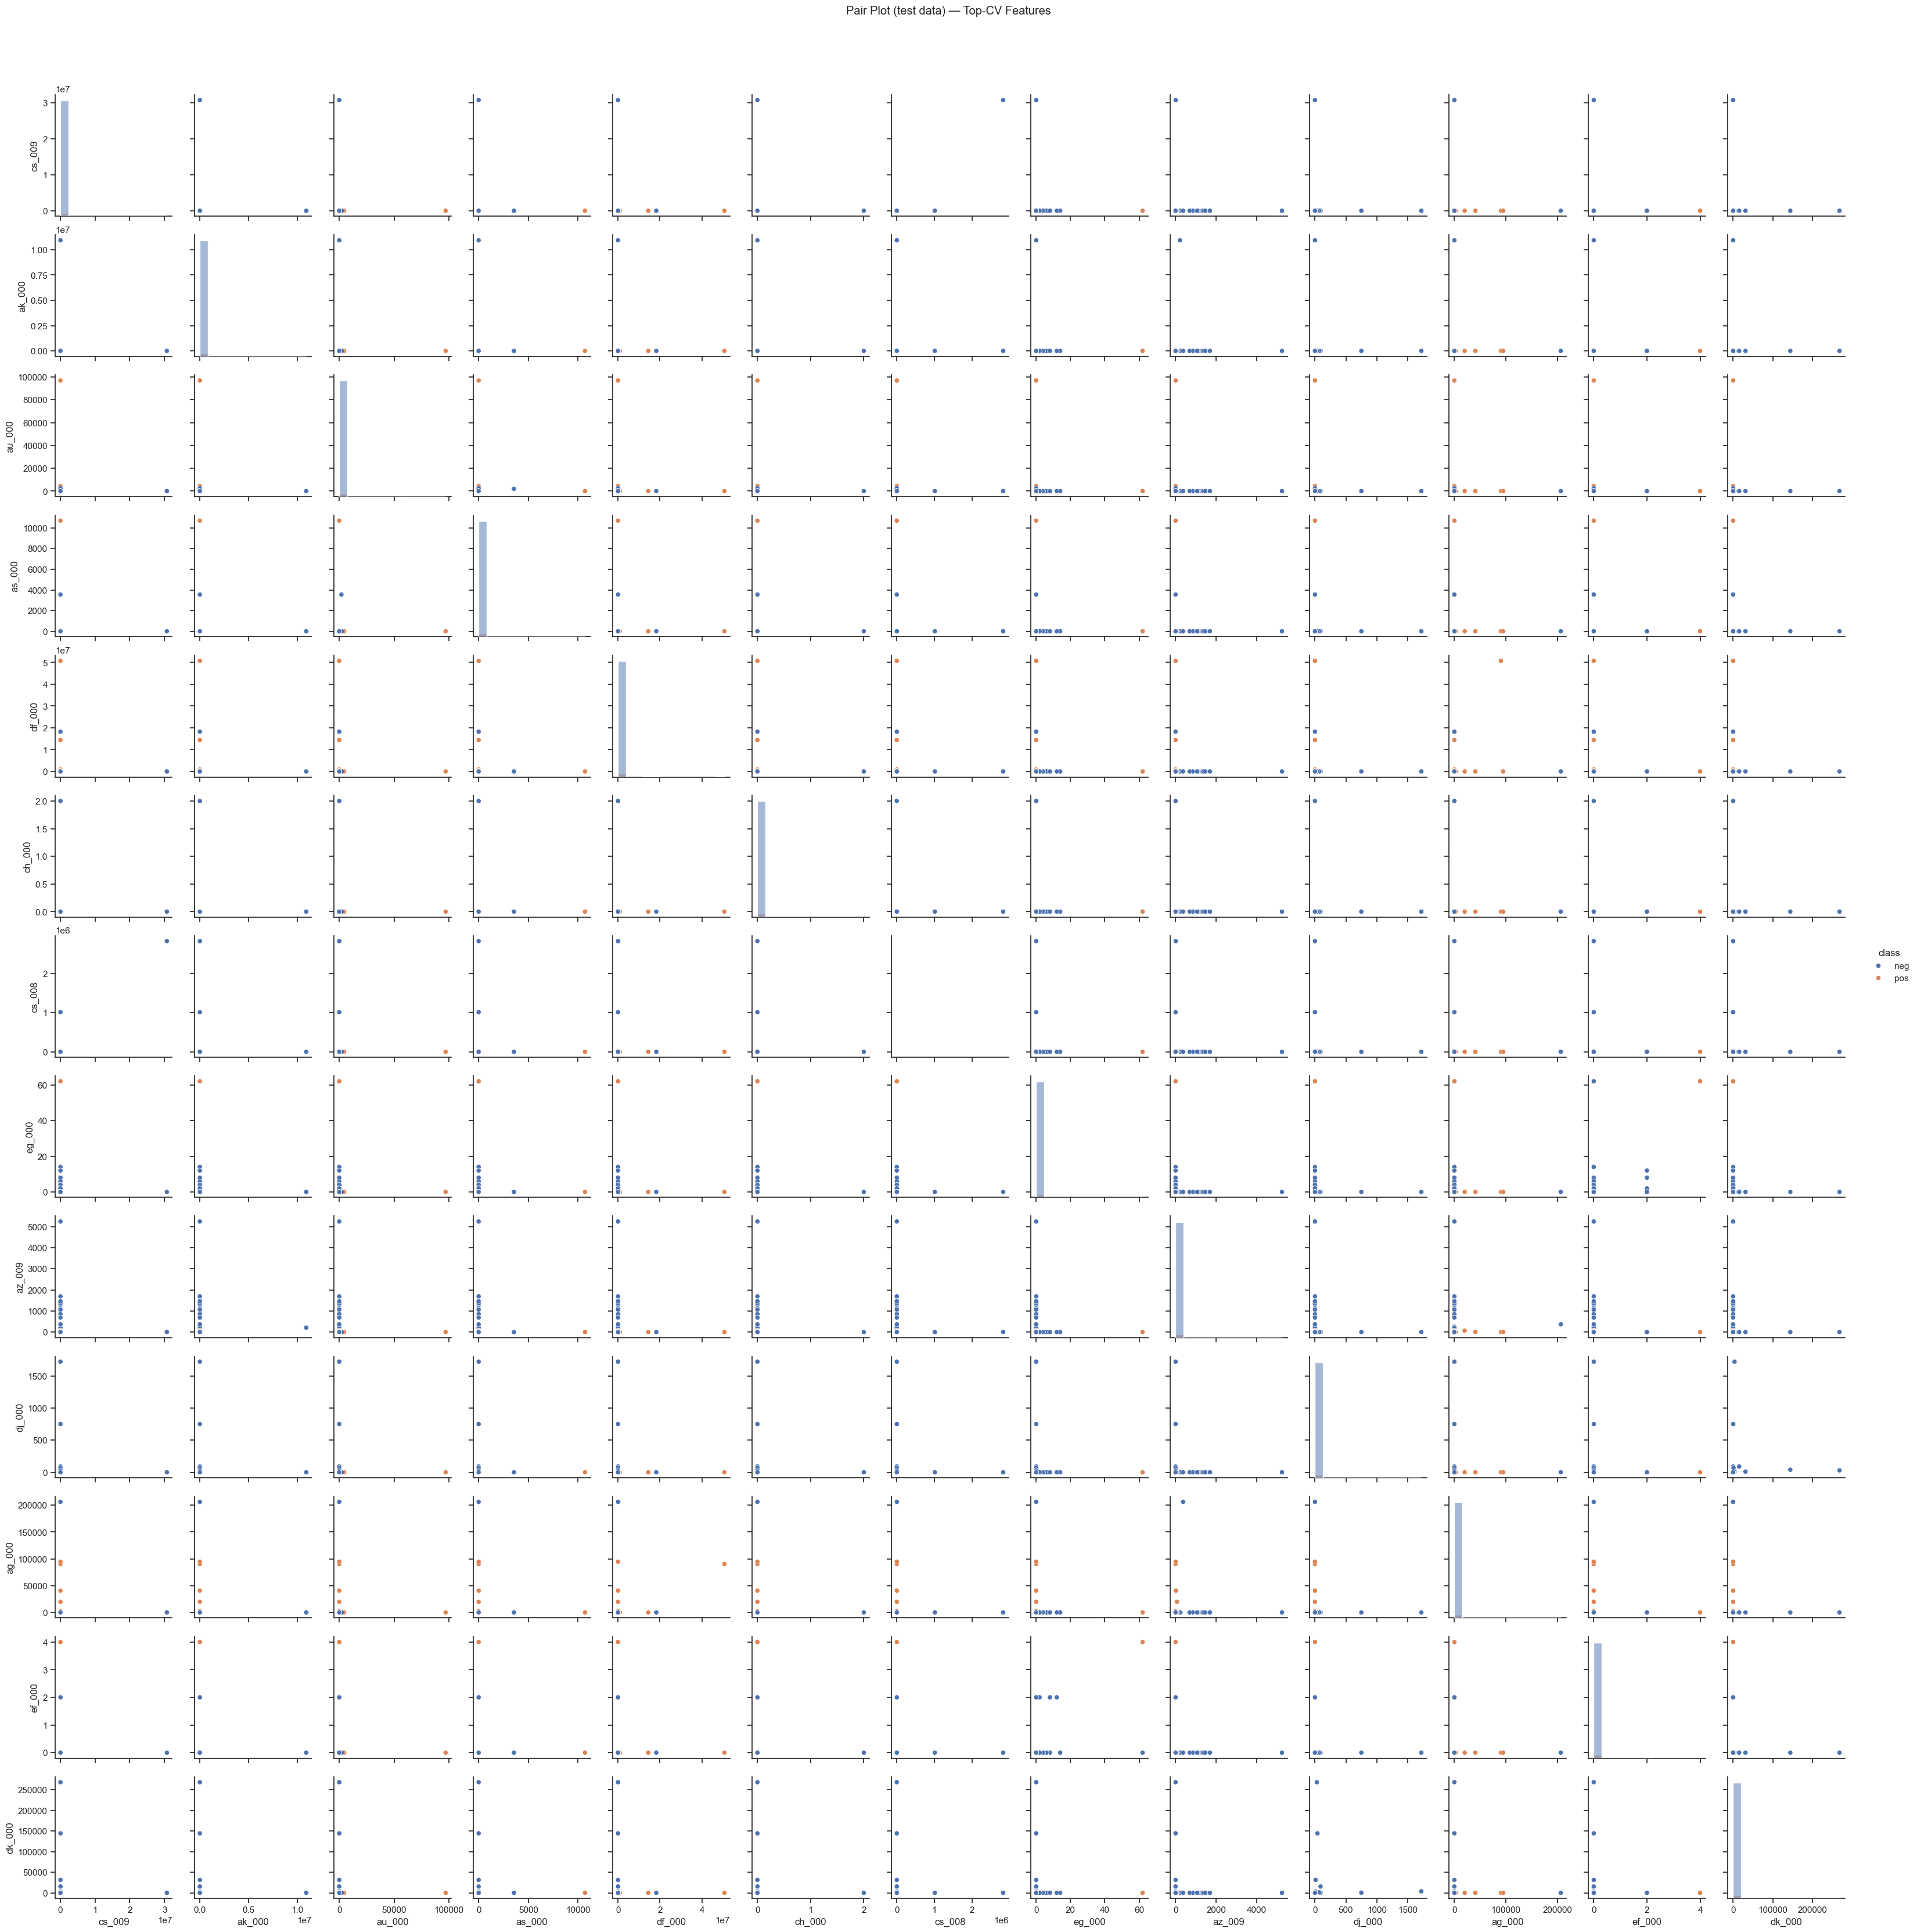

In [71]:
X_train_cv_sorted = X_train_cv_df.sort_values(by='CV', ascending=False)
X_test_cv_sorted = X_test_cv_df.sort_values(by='CV', ascending=False)

top_k = int(np.floor(np.sqrt(170)))   # = 13
top_train_features = X_train_cv_sorted['Feature'].head(top_k).tolist()
top_test_features  = X_test_cv_sorted['Feature'].head(top_k).tolist()

print(f"Top {top_k} train features by CV:\n", top_train_features)
print(f"\nTop {top_k} test features by CV:\n", top_test_features)

# ---- Train ----
train_vis = pd.concat([
    X_train_imputed[top_train_features].reset_index(drop=True),
    y_train.reset_index(drop=True)
], axis=1)
train_vis['class'] = pd.Categorical(train_vis['class'], categories=['neg', 'pos'])

train_sample = train_vis.sample(n=3000, random_state=11)

sns.pairplot(
    train_sample,
    vars=top_train_features,
    hue='class',
    diag_kind='hist'
)
plt.suptitle("Pair Plot (train data) — Top-CV Features", y=1.03)
plt.show()

# ---- Test ----
test_vis = pd.concat([
    X_test_imputed[top_test_features].reset_index(drop=True),
    y_test.reset_index(drop=True)
], axis=1)
test_vis['class'] = pd.Categorical(test_vis['class'], categories=['neg', 'pos'])

test_sample = test_vis.sample(n=3000, random_state=11)

sns.pairplot(
    test_sample,
    vars=top_test_features,
    hue='class',
    diag_kind='hist'
)
plt.suptitle("Pair Plot (test data) — Top-CV Features", y=1.03)
plt.show()


To draw the boxplot, we will apply the z-score normalization to make the features comparable on one scale. And we ignore the outliers to check the main pattern.

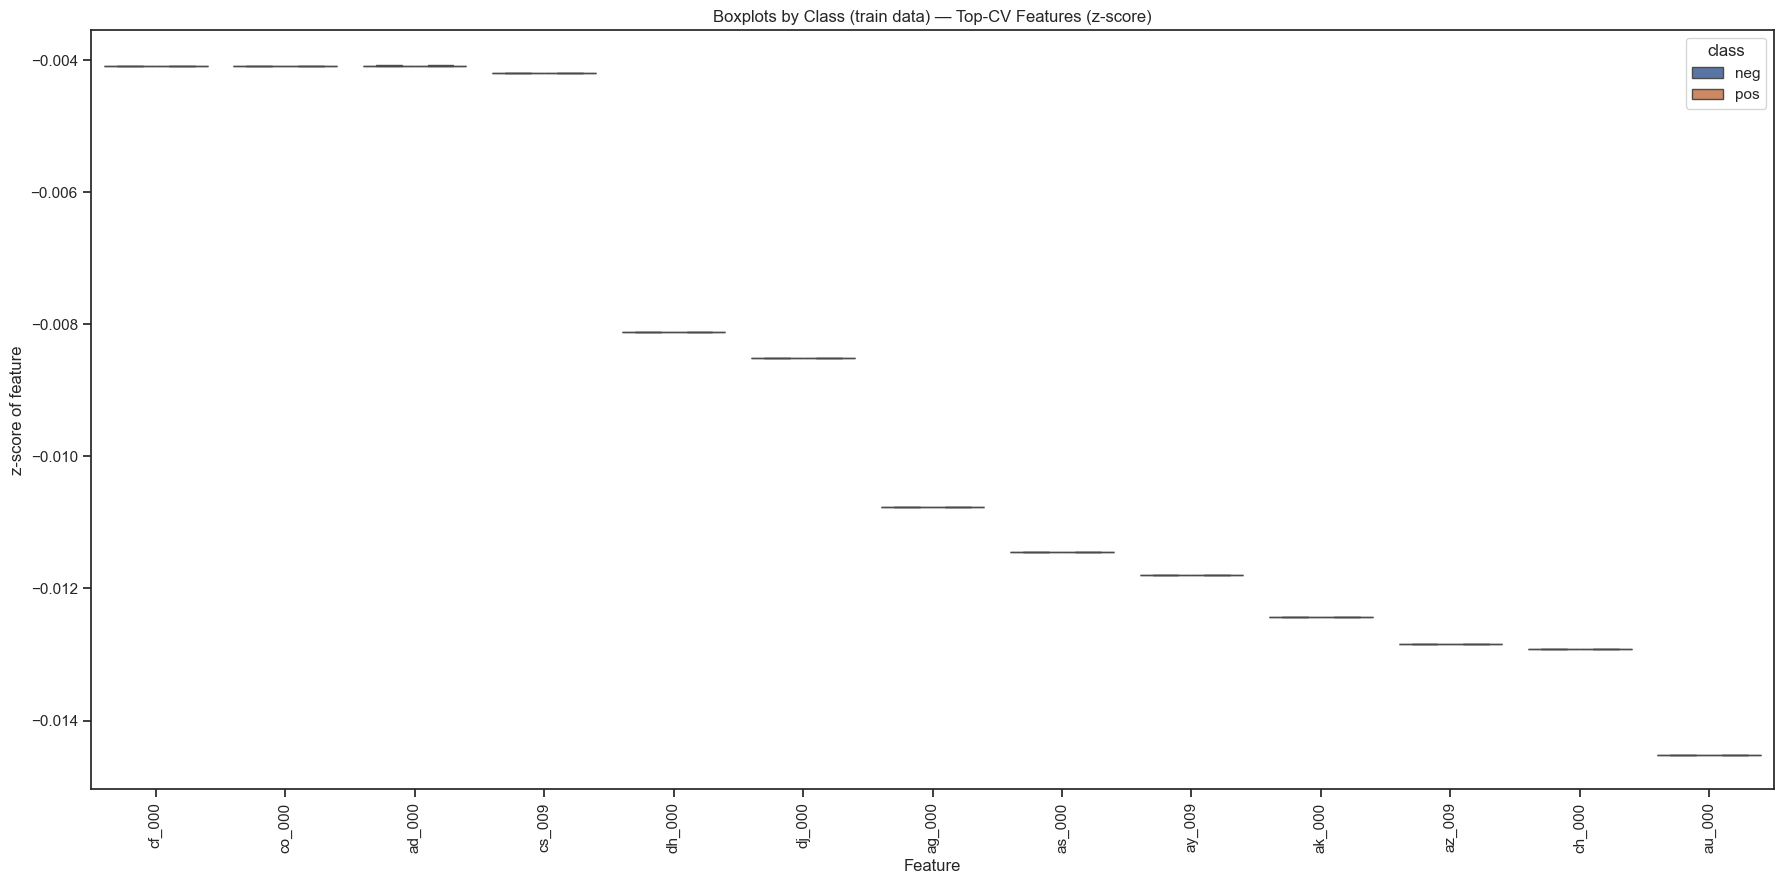

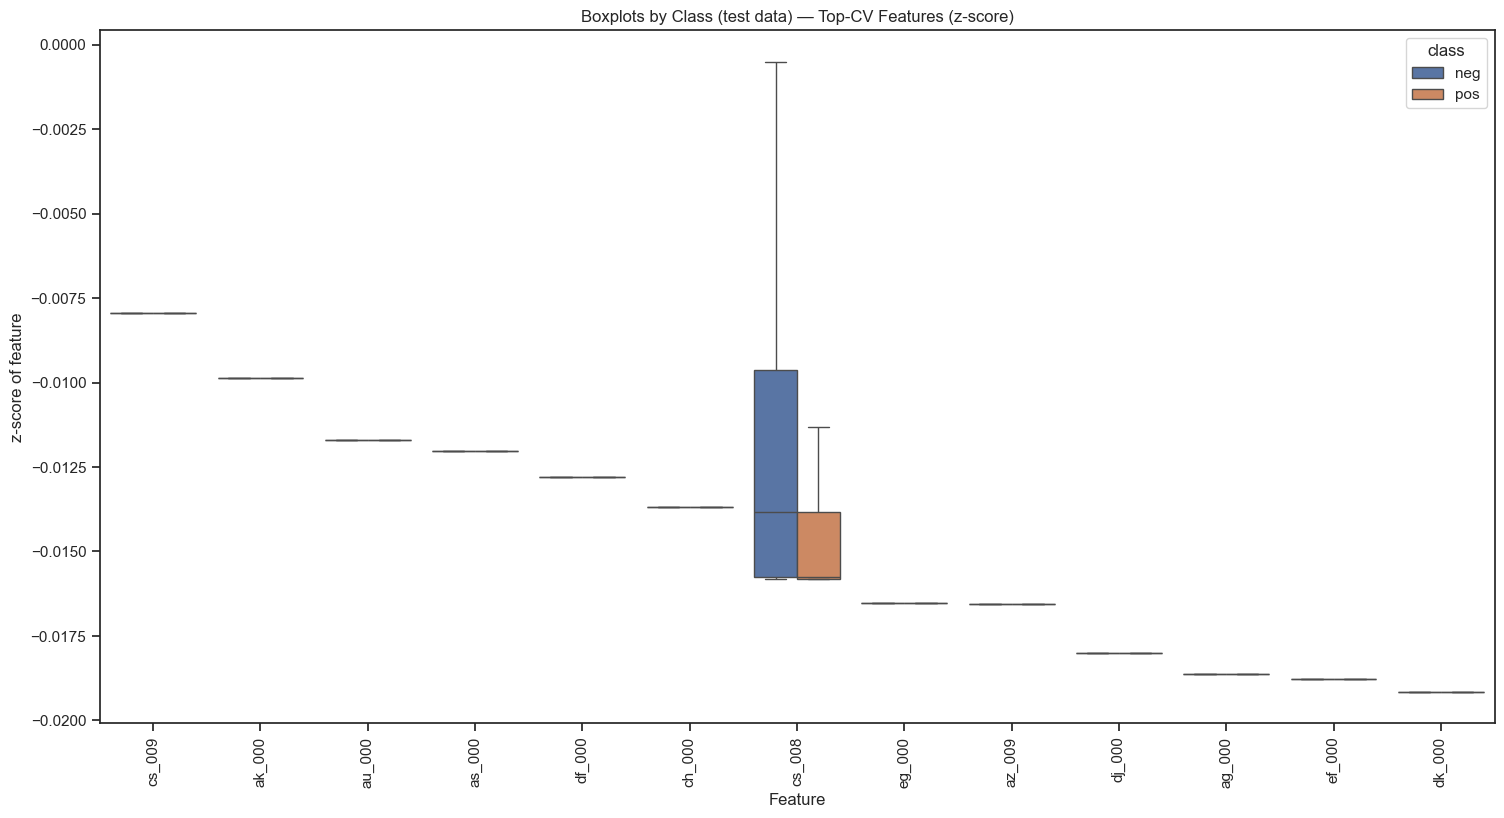

In [72]:
# ---- train ----
train_melted = train_vis.melt(
    id_vars="class",
    value_vars=top_train_features,
    var_name="Feature",
    value_name="Value"
)

# normalize data
train_long_z = train_melted.copy()
train_long_z["Value_z"] = train_long_z.groupby("Feature")["Value"] \
                                      .transform(lambda s: (s - s.mean()) / s.std(ddof=0))

plt.figure(figsize=(18,9))
sns.boxplot(
    data=train_long_z, x="Feature", y="Value_z", hue="class",
    showfliers=False
)
plt.title("Boxplots by Class (train data) — Top-CV Features (z-score)")
plt.ylabel("z-score of feature")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ---- test ----
test_melted = test_vis.melt(
    id_vars="class",
    value_vars=top_test_features,
    var_name="Feature",
    value_name="Value"
)

# normalize data
test_long_z = test_melted.copy()
test_long_z["Value_z"] = test_long_z.groupby("Feature")["Value"] \
                                    .transform(lambda s: (s - s.mean()) / s.std(ddof=0))

plt.figure(figsize=(18,9))
sns.boxplot(
    data=test_long_z, x="Feature", y="Value_z", hue="class",
    showfliers=False
)
plt.title("Boxplots by Class (test data) — Top-CV Features (z-score)")
plt.ylabel("z-score of feature")
plt.xticks(rotation=90)
plt.show()

#### (v) Is this data set imbalanced?

In [73]:
print("=== Training set class counts ===")
print(y_train.value_counts())

print("\n=== Test set class counts ===")
print(y_test.value_counts())

=== Training set class counts ===
class
neg    59000
pos     1000
Name: count, dtype: int64

=== Test set class counts ===
class
neg    15625
pos      375
Name: count, dtype: int64


As we can tell from the summary, in both train and test set, there are much more data in neg than data points of pos. The data sets are highly imbalanced.

### (c) Train a random forest

- Step 1: train random forest model for train and test 

=== Train ===
Confusion matrix:
[[59000     0]
 [    0  1000]]
Accuracy: 1.0000   Misclassification: 0.0000
AUC: 1.0000


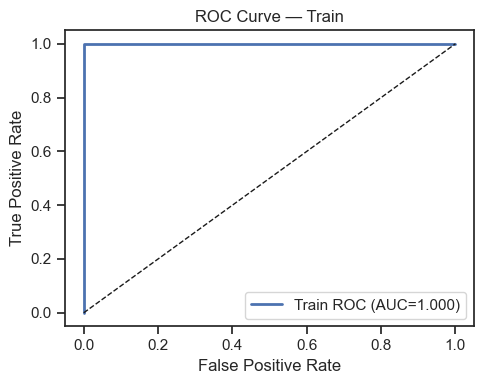

=== Test ===
Confusion matrix:
[[15607    18]
 [  106   269]]
Accuracy: 0.9922   Misclassification: 0.0078
AUC: 0.9954


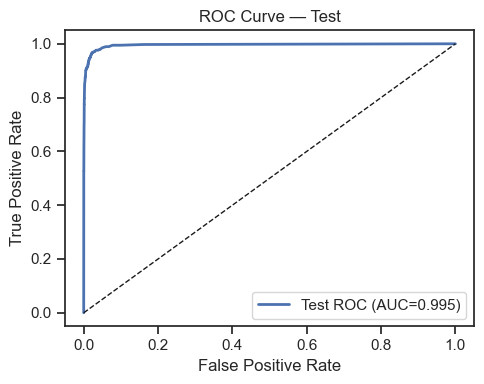

=== OOB vs Test Error ===
OOB accuracy: 0.9942   OOB error: 0.0058
Test accuracy: 0.9922  Test error: 0.0078


In [74]:
y_train_bin = y_train.map({'neg': 0, 'pos': 1}).astype(int)
y_test_bin  = y_test.map({'neg': 0, 'pos': 1}).astype(int)

rf = RandomForestClassifier(
    n_estimators=400,
    oob_score=True,
    n_jobs=-1,
    random_state=11
)
rf.fit(X_train_imputed, y_train_bin)

# Train
train_pred = rf.predict(X_train_imputed)
train_proba_pos = rf.predict_proba(X_train_imputed)[:, 1]

# Test
test_pred = rf.predict(X_test_imputed)
test_proba_pos = rf.predict_proba(X_test_imputed)[:, 1]


def rf_cal(name, y_true, y_pred, y_proba_pos):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    acc = accuracy_score(y_true, y_pred)
    miscls = 1.0 - acc
    auc = roc_auc_score(y_true, y_proba_pos)
    fpr, tpr, thr = roc_curve(y_true, y_proba_pos)

    print(f"=== {name} ===")
    print("Confusion matrix:")
    print(cm)
    print(f"Accuracy: {acc:.4f}   Misclassification: {miscls:.4f}")
    print(f"AUC: {auc:.4f}")

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, lw=2, label=f'{name} ROC (AUC={auc:.3f})')
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

rf_cal("Train", y_train_bin, train_pred, train_proba_pos)
rf_cal("Test",  y_test_bin,  test_pred,  test_proba_pos)


oob_accuracy = rf.oob_score_
oob_error = 1.0 - oob_accuracy

test_accuracy = accuracy_score(y_test_bin, test_pred)
test_error = 1.0 - test_accuracy

print("=== OOB vs Test Error ===")
print(f"OOB accuracy: {oob_accuracy:.4f}   OOB error: {oob_error:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}  Test error: {test_error:.4f}")

From the outputs we can tell the model fits the training data very well, but when it comes to the test data, the accuracy becomes lower.

And the OOB error is less than the test error.

### (d) Research class imbalance in random forest

=== Train (balanced) ===
Confusion matrix:
[[59000     0]
 [    0  1000]]
Accuracy: 1.0000   Misclassification: 0.0000
AUC: 1.0000


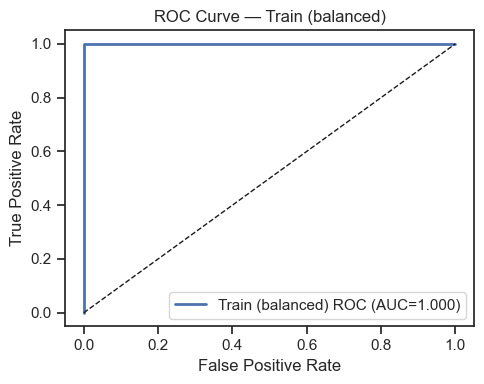

=== Test (balanced) ===
Confusion matrix:
[[15608    17]
 [  160   215]]
Accuracy: 0.9889   Misclassification: 0.0111
AUC: 0.9934


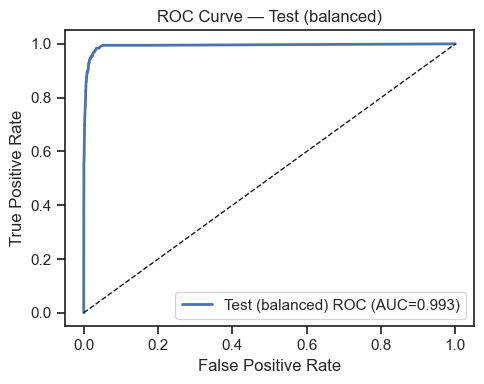

=== OOB vs Test Error (balanced RF) ===
OOB accuracy: 0.9923   OOB error: 0.0077
Test accuracy: 0.9889  Test error: 0.0111


In [75]:
rf_balanced = RandomForestClassifier(
    n_estimators=400,
    oob_score=True,
    class_weight="balanced",
    n_jobs=-1,
    random_state=11
)
rf_balanced.fit(X_train_imputed, y_train_bin)

train_pred_bal = rf_balanced.predict(X_train_imputed)
test_pred_bal  = rf_balanced.predict(X_test_imputed)

train_proba_bal = rf_balanced.predict_proba(X_train_imputed)[:, 1]
test_proba_bal  = rf_balanced.predict_proba(X_test_imputed)[:, 1]


def rfb_cal(name, y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    acc = accuracy_score(y_true, y_pred)
    miscls = 1 - acc
    auc = roc_auc_score(y_true, y_proba)
    fpr, tpr, thr = roc_curve(y_true, y_proba)

    print(f"=== {name} ===")
    print("Confusion matrix:")
    print(cm)
    print(f"Accuracy: {acc:.4f}   Misclassification: {miscls:.4f}")
    print(f"AUC: {auc:.4f}")

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, lw=2, label=f'{name} ROC (AUC={auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


rfb_cal("Train (balanced)", y_train_bin, train_pred_bal, train_proba_bal)
rfb_cal("Test (balanced)",  y_test_bin,  test_pred_bal,  test_proba_bal)


oob_acc_bal = rf_balanced.oob_score_
oob_err_bal = 1 - oob_acc_bal

test_acc_bal = accuracy_score(y_test_bin, test_pred_bal)
test_err_bal = 1 - test_acc_bal

print("=== OOB vs Test Error (balanced RF) ===")
print(f"OOB accuracy: {oob_acc_bal:.4f}   OOB error: {oob_err_bal:.4f}")
print(f"Test accuracy: {test_acc_bal:.4f}  Test error: {test_err_bal:.4f}")

Compare the performance of two random forests, both models perfectly fit the training data. The balanced RF has slightly lower accuracy and AUC. And the OOB error and test error are both higher in the balanced RF result.

Maybe this is because the default cutoff of ``class_weighted="balanced"`` is 0.5, and this is not a proper threshold for our data. So it causes the misclassification becomes higher in the balanced model.

### (e) XGBoost and Model Trees

Here we use the 5-fold cross validation method to calculate the error.

Best reg_alpha from 5-fold CV: 0
Best mean CV AUC: 0.9891
Out-of-fold CV AUC: 0.9887
Out-of-fold CV error: 0.0062
=== Train (XGBoost) ===
Confusion matrix [rows=true, cols=pred]:
[[59000     0]
 [    1   999]]
Accuracy: 1.0000   Misclassification: 0.0000
AUC: 1.0000


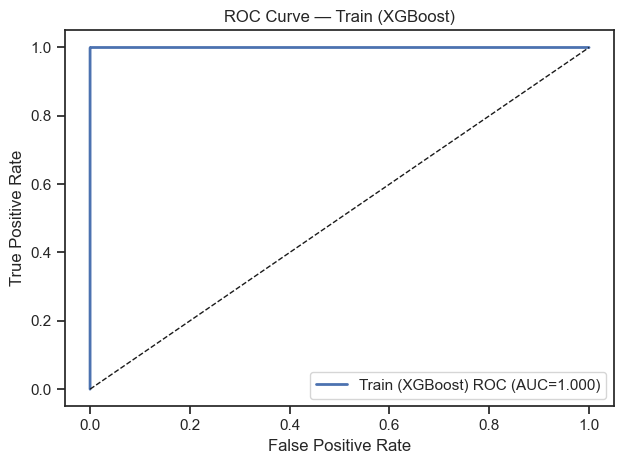

=== Test (XGBoost) ===
Confusion matrix [rows=true, cols=pred]:
[[15597    28]
 [   91   284]]
Accuracy: 0.9926   Misclassification: 0.0074
AUC: 0.9945


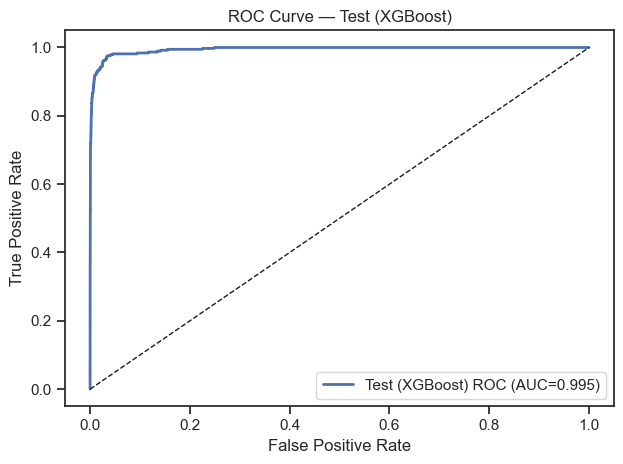

=== CV vs Test Error ===
5-fold CV error: 0.0062
Test error: 0.0074


In [76]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=11)

param_grid = {"reg_alpha": [0, 0.01, 0.1, 0.5, 1, 2, 5, 10]}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train_imputed, y_train_bin)

best_alpha = grid.best_params_["reg_alpha"]
print(f"Best reg_alpha from 5-fold CV: {best_alpha}")
print(f"Best mean CV AUC: {grid.best_score_:.4f}")


xgb_best = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    reg_alpha=best_alpha,
    random_state=11
)

oof_proba = cross_val_predict(
    xgb_best, X_train_imputed, y_train_bin,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

oof_pred = (oof_proba >= 0.5).astype(int)
cv_acc = accuracy_score(y_train_bin, oof_pred)
cv_error = 1 - cv_acc
cv_auc = roc_auc_score(y_train_bin, oof_proba)
print(f"Out-of-fold CV AUC: {cv_auc:.4f}")
print(f"Out-of-fold CV error: {cv_error:.4f}")


xgb_best.fit(X_train_imputed, y_train_bin)


def xgboost_cal(name, y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    acc = accuracy_score(y_true, y_pred)
    mis = 1 - acc
    auc = roc_auc_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    print(f"=== {name} ===")
    print("Confusion matrix [rows=true, cols=pred]:")
    print(cm)
    print(f"Accuracy: {acc:.4f}   Misclassification: {mis:.4f}")
    print(f"AUC: {auc:.4f}")

    # plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} ROC (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--',lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    return mis

train_proba = xgb_best.predict_proba(X_train_imputed)[:, 1]
mis_train = xgboost_cal("Train (XGBoost)", y_train_bin, train_proba)

test_proba = xgb_best.predict_proba(X_test_imputed)[:, 1]
mis_test = xgboost_cal("Test (XGBoost)", y_test_bin, test_proba)


print("=== CV vs Test Error ===")
print(f"5-fold CV error: {cv_error:.4f}")
print(f"Test error: {mis_test:.4f}")


### (f) Use SMOTE to pre-process your data

Best reg_alpha (SMOTE) from 5-fold CV: 0.1
Best mean CV AUC: 0.9987
Out-of-fold CV AUC (SMOTE): 0.9987
Out-of-fold CV error (SMOTE): 0.0147

=== Train (XGBoost + SMOTE) ===
Confusion matrix [rows=true, cols=pred]:
[[6000    0]
 [   0 6000]]
Accuracy: 1.0000   Misclassification: 0.0000
AUC: 1.0000


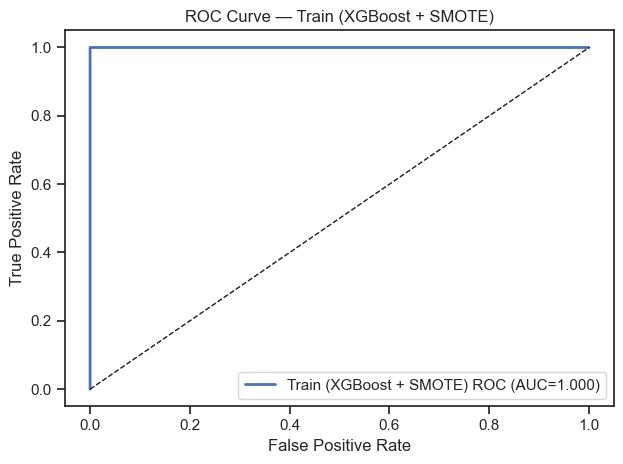


=== Test (XGBoost + SMOTE) ===
Confusion matrix [rows=true, cols=pred]:
[[15364   261]
 [   28   347]]
Accuracy: 0.9819   Misclassification: 0.0181
AUC: 0.9946


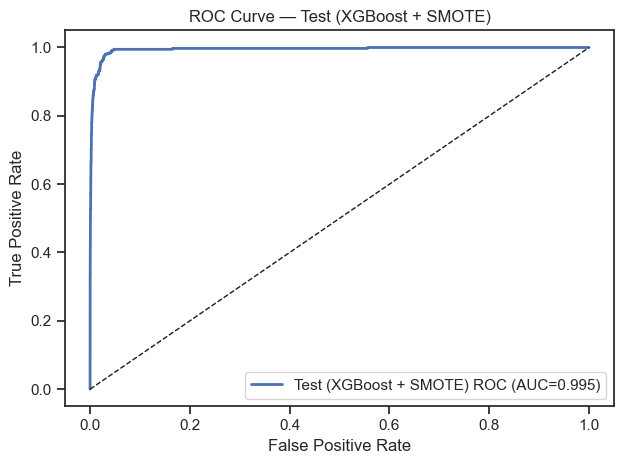


=== CV vs Test Error (SMOTE) ===
5-fold CV error: 0.0147
Test error: 0.0181


In [82]:
# Downsample data
X_train_df = X_train_imputed.copy()
y_train_df = y_train_bin.copy()

X_majority = X_train_df[y_train_df == 0]
X_minority = X_train_df[y_train_df == 1]

y_majority = y_train_df[y_train_df == 0]
y_minority = y_train_df[y_train_df == 1]

X_majority_down, y_majority_down = resample(
    X_majority, y_majority,
    replace=False, n_samples=6000, random_state=11
)

X_train_down = np.vstack((X_majority_down, X_minority))
y_train_down = np.concatenate((y_majority_down, y_minority))

# apply SMOTE
smote = SMOTE(random_state=11)
X_train_smote, y_train_smote = smote.fit_resample(X_train_down, y_train_down)

# 5 fold cv
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=11)
param_grid = {"reg_alpha": [0, 0.01, 0.1, 0.5, 1, 2, 5, 10]}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)
grid.fit(X_train_smote, y_train_smote)

best_alpha = grid.best_params_["reg_alpha"]
print(f"Best reg_alpha (SMOTE) from 5-fold CV: {best_alpha}")
print(f"Best mean CV AUC: {grid.best_score_:.4f}")


xgb_best = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    reg_alpha=best_alpha,
    random_state=11
)

oof_proba = cross_val_predict(
    xgb_best, X_train_smote, y_train_smote,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]
oof_pred = (oof_proba >= 0.5).astype(int)
cv_acc = accuracy_score(y_train_smote, oof_pred)
cv_error = 1 - cv_acc
cv_auc = roc_auc_score(y_train_smote, oof_proba)
print(f"Out-of-fold CV AUC (SMOTE): {cv_auc:.4f}")
print(f"Out-of-fold CV error (SMOTE): {cv_error:.4f}")

xgb_best.fit(X_train_smote, y_train_smote)

def xgb_result(name, y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    acc = accuracy_score(y_true, y_pred)
    mis = 1 - acc
    auc = roc_auc_score(y_true, y_proba)
    print(f"\n=== {name} ===")
    print("Confusion matrix [rows=true, cols=pred]:")
    print(cm)
    print(f"Accuracy: {acc:.4f}   Misclassification: {mis:.4f}")
    print(f"AUC: {auc:.4f}")
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} ROC (AUC={auc:.3f})')
    plt.plot([0,1],[0,1],'k--',lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    return mis

train_proba = xgb_best.predict_proba(X_train_smote)[:, 1]
mis_train = xgb_result("Train (XGBoost + SMOTE)", y_train_smote, train_proba)

test_proba = xgb_best.predict_proba(X_test_imputed)[:, 1]
mis_test = xgb_result("Test (XGBoost + SMOTE)", y_test_bin, test_proba)

print("\n=== CV vs Test Error (SMOTE) ===")
print(f"5-fold CV error: {cv_error:.4f}")
print(f"Test error: {mis_test:.4f}")


To summarize and compare the model without compensation and with SMOTE, we use the 5-fold cv for both cases, the model with SMOTE has a higher AUC than the uncompensated model (0.9987 vs. 0.9891), but has a higher misclassification (0.9987 vs. 0.9891). The test error is lower of the uncompensated model (0.0074 vs. 0.0181).

Because there is an increase in misclassification, that means the false negative is higher with SMOTE. It is still highly possible that the default 0.5 cutoff is not optimal in this case.

## 2. ISLR 6.6.3

### (a) Training RSS

Answer: iv. steadily decrease

When $s = 0$, that means all the $\beta_j 's$ are 0. It means the model is strictly constrained. And as s increases, the model is more and more complex. The model will fit the training data better and better. So the training RSS will steadily decrease.

### (b) Test RSS

Answer: ii. decrease initially, then eventually start increasing (U-shape)

WHen s is small, the model has less complexity and high bias. So the model is underfitting. It will have high test RSS. As s increases, the bias decreases and the test RSS decreases. But when s becomes large, it will lead to overfitting. The test RSS will increase again. So the test RSS will form as a u-shaped curve.

### (c) Variance

Answer: iii steadily increase

When s increases, there will be more non-zero $\beta_j 's$ and the model will become more and more complex. As the model become more flexible, it will be sensitive to noise. So the variance will increase monotonically with s.

### (d) (Squared) bias

Answer: iv. steadily decrease

When s increases, the model will become more and more complex and the variance will increase. As the constriant become loose, the bias will decrease.

### (e) Irreducible error

Answer: v. remain constant

The irreducible error depends on the noise of the data, and it is not affected by the complexity of the model. So no matter how s change, the irreducible error remains constant.


## 3. ISLR 6.6.5

### (a) Ridge regression optimization

Given centered data and $\hat\beta_0=0$, ridge solves:

$$
\min_{\beta_1,\beta_2}
\sum_{i=1}^{2}\big(y_i-\beta_1 x_{i1}-\beta_2 x_{i2}\big)^2
+\lambda(\beta_1^2+\beta_2^2)
$$

Given $\hat{\beta}_0 = 0$ and $n=2, p=2$:

$$L_{Ridge} = (y_1 - x_{11}\hat{\beta}_1 - x_{12}\hat{\beta}_2)^2 + (y_2 - x_{21}\hat{\beta}_1 - x_{22}\hat{\beta}_2)^2 + \lambda(\hat{\beta}_1^2 + \hat{\beta}_2^2)$$

Applying the constraints $x_{11} = x_{12}$ and $x_{21} = x_{22}$:

$$\text{Minimize} \left[ (y_1 - x_{11}(\hat{\beta}_1 + \hat{\beta}_2))^2 + (y_2 - x_{21}(\hat{\beta}_1 + \hat{\beta}_2))^2 + \lambda(\hat{\beta}_1^2 + \hat{\beta}_2^2) \right]  w.r.t  \hat{\beta}_1, \hat{\beta}_2 $$

### (b) $\hat{\beta}_1 = \hat{\beta}_2$

Let the objective function from (a) be $L(\hat{\beta}_1, \hat{\beta}_2)$. Notice that the RSS terms depend on $\hat{\beta}_1$ and $\hat{\beta}_2$ only through their sum $(\hat{\beta}_1 + \hat{\beta}_2)$, which is symmetric. The penalty term $\lambda(\hat{\beta}_1^2 + \hat{\beta}_2^2)$ is also symmetric.

$$L(\hat{\beta}_1, \hat{\beta}_2) = L(\hat{\beta}_2, \hat{\beta}_1)$$

Because the objective function is symmetric with respect to $\hat{\beta}_1$ and $\hat{\beta}_2$ and is strictly convex (due to the $\lambda > 0$ and the squared L2 norm), the minimum has only one possibility, which is $\hat{\beta}_1 = \hat{\beta}_2$.

### (c) Lasso optimization

The lasso optimization problem seeks to minimize:

$$L_{Lasso} = \sum_{i=1}^2 (y_i - \hat{\beta}_0 - \sum_{j=1}^2 x_{ij}\hat{\beta}_j)^2 + \lambda \sum_{j=1}^2 |\hat{\beta}_j|$$

Applying the given constraints:

$$\text{Minimize}_{\hat{\beta}_1, \hat{\beta}_2} \left[ (y_1 - x_{11}(\hat{\beta}_1 + \hat{\beta}_2))^2 + (y_2 - x_{21}(\hat{\beta}_1 + \hat{\beta}_2))^2 + \lambda(|\hat{\beta}_1| + |\hat{\beta}_2|) \right]$$

### (d) $\hat{\beta}_1$ and $\hat{\beta}_2$ are not unique

Let $s = \hat{\beta}_1 + \hat{\beta}_2$. The RSS part of the objective function, $\text{RSS}(s) = (y_1 - x_{11}s)^2 + (y_2 - x_{21}s)^2$, depends only on this sum $s$.

Let $s^*$ be the value of $s$ that minimizes the overall objective. The problem reduces to minimizing the penalty $\lambda(|\hat{\beta}_1| + |\hat{\beta}_2|)$ subject to the constraint $\hat{\beta}_1 + \hat{\beta}_2 = s^*$.

Unlike the L2 norm, the L1 norm is not strictly convex. If $s^* > 0$, any pair $(\hat{\beta}_1, \hat{\beta}_2)$ such that $\hat{\beta}_1 \ge 0$, $\hat{\beta}_2 \ge 0$, and $\hat{\beta}_1 + \hat{\beta}_2 = s^*$ gives the *exact same* penalty value: $\lambda(\hat{\beta}_1 + \hat{\beta}_2) = \lambda s^*$.

So the solution is not unique. The set of solutions lies on $\hat{\beta}_1 + \hat{\beta}_2 = s^*$. The minimum only requires a fixed sum.

## 4. ISLR 8.4.5

- Majority vote: Red

    This will classify as the label with more frequency (6 Red and 4 Green)

- Average probability: Green

    The mean probability of all the estimates is 0.45 < 0.5, so it will predict as Green.

## 5. ISLR 9.7.3

### (a) Sketch the observations

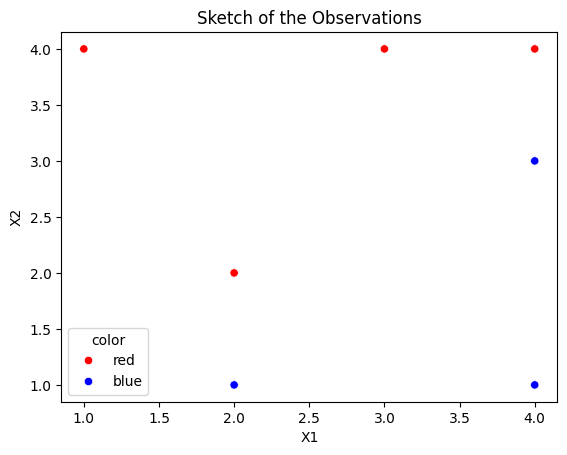

In [ ]:
df_obs = pd.DataFrame({
    "x1": [3, 2, 4, 1, 2, 4, 4],
    "x2": [4, 2, 4, 4, 1, 3, 1],
    "color": ["red", "red", "red", "red", "blue", "blue", "blue"]
})

sns.scatterplot(data=df_obs, x="x1", y="x2", hue="color", palette=["red", "blue"])
plt.title("Sketch of the Observations")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

### (b) Optimal separating hyperplane

Equation: -2.00*X1 + 2.00*X2 + 1.00 = 0


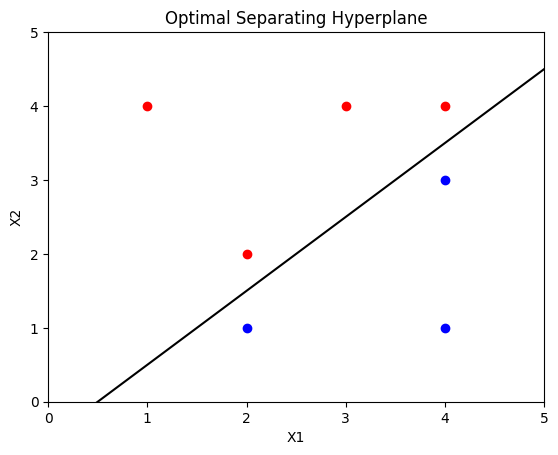

In [ ]:
X = [[3,4],[2,2],[4,4],[1,4],[2,1],[4,3],[4,1]]
y = [1,1,1,1,-1,-1,-1]

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y)

w = clf.coef_[0]
b = clf.intercept_[0]
print(f"Equation: {w[0]:.2f}*X1 + {w[1]:.2f}*X2 + {b:.2f} = 0")

# plot
plt.scatter([x[0] for x in X[:4]], [x[1] for x in X[:4]], color='red')
plt.scatter([x[0] for x in X[4:]], [x[1] for x in X[4:]], color='blue')

x1 = [0,5]
x2 = [-(w[0]*x + b)/w[1] for x in x1]
plt.plot(x1, x2, 'k-')
plt.xlim(0,5)
plt.ylim(0,5)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Optimal Separating Hyperplane')
plt.show()

### (c) Classification rule

The equation given by (b) is $f(X) = -2 \times X_1 + 2 \times X_2 + 1$. So the classification rule is if $f(X) = -2 \times X_1 + 2 \times X_2 + 1 > 0$ then classify to Red, otherwise classify to Blue.

### (d) Sketch the maximal margin hyperplane

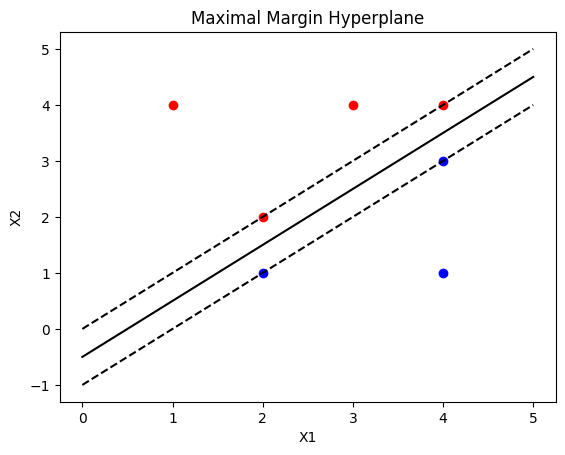

In [ ]:
x1 = np.linspace(0,5,100)

boundary = -(w[0]*x1 + b)/w[1]

margin_pos = -(w[0]*x1 + b - 1)/w[1]
margin_neg = -(w[0]*x1 + b + 1)/w[1]

plt.scatter([x[0] for x in X[:4]], [x[1] for x in X[:4]], color='red')
plt.scatter([x[0] for x in X[4:]], [x[1] for x in X[4:]], color='blue')
plt.plot(x1, boundary, 'k-')
plt.plot(x1, margin_pos, 'k--')
plt.plot(x1, margin_neg, 'k--')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Maximal Margin Hyperplane')
plt.show()

### (e) Support vectors for the maximal margin classifier

The support vectors are the points that are exactly on the maximal margin hyperplane.

Support vector indices: [4 5 1 2]
Support vector coordinates:
 [[2. 1.]
 [4. 3.]
 [2. 2.]
 [4. 4.]]


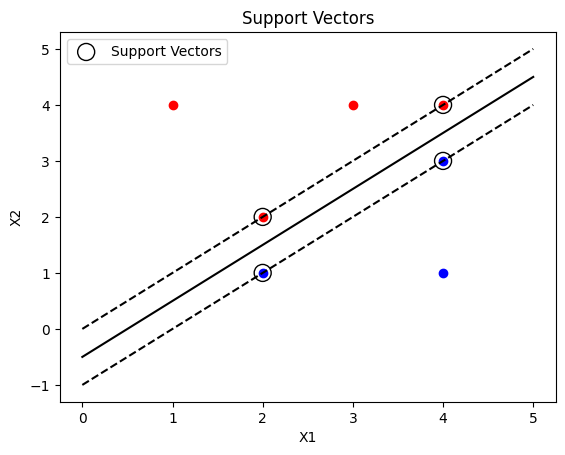

In [ ]:
print("Support vector indices:", clf.support_)
print("Support vector coordinates:\n", clf.support_vectors_)

plt.scatter([x[0] for x in X[:4]], [x[1] for x in X[:4]], color='red')
plt.scatter([x[0] for x in X[4:]], [x[1] for x in X[4:]], color='blue')

plt.plot(x1, boundary, 'k-')
plt.plot(x1, margin_pos, 'k--')
plt.plot(x1, margin_neg, 'k--')

plt.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
            s=150, facecolors='none', edgecolors='k', label='Support Vectors')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Support Vectors')
plt.legend()
plt.show()

### (f) Movement of seventh observation

First of all, the observation 7, (4,1) is not a support vector. We can see from the graph that it is far away from the boundry and the maximal margin hyperplane. A slight movement of it will not change the fact that it is far away below the boundry. It won't become a support vector after the movement. Only the support vectors' movement will cause change to the maximal margin hyperplane. So a slight movement of ovservation 7 won't affect the maximal margin hyper]lane.

### (g) Sketch a non-optimal separating hyperplane

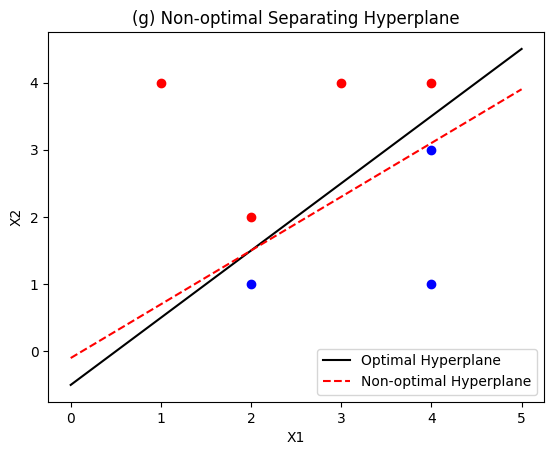

In [ ]:
x1 = np.linspace(0,5,100)

boundary_opt = x1 - 0.5

boundary_nonopt = 0.8*x1 - 0.1

plt.scatter([x[0] for x in X[:4]], [x[1] for x in X[:4]], color='red')
plt.scatter([x[0] for x in X[4:]], [x[1] for x in X[4:]], color='blue')
plt.plot(x1, boundary_opt, 'k-', label='Optimal Hyperplane')
plt.plot(x1, boundary_nonopt, 'r--', label='Non-optimal Hyperplane')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('(g) Non-optimal Separating Hyperplane')
plt.legend()
plt.show()

The non-opitmal equation here is $f(X) = -0.1 + 0.8X_1 - 1.0X_2$. We can see it can still classify the data but not as good as the optimal one.

### (h) Add an additional observation

Adding a new Red point (4, 0.8) here. After adding this point, the two classes are no longer separable by a hyperplane.

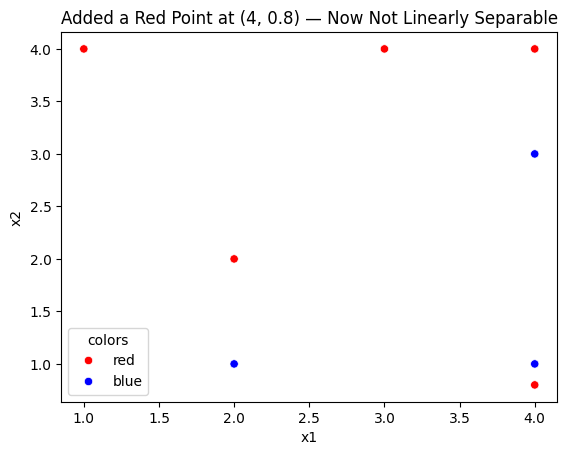

In [ ]:
# Add new Red point (4, 0.8)
x1 = [3, 2, 4, 1, 2, 4, 4, 4]
x2 = [4, 2, 4, 4, 1, 3, 1, 0.8]
colors = ["red", "red", "red", "red", "blue", "blue", "blue","red"]

df_obs = pd.DataFrame(dict(x1=x1, x2=x2, colors=colors))

sns.scatterplot(data=df_obs, x='x1', y='x2', hue='colors', palette=['red','blue'])
plt.title('Added a Red Point at (4, 0.8) — Now Not Linearly Separable')
plt.show()


### References:

1. https://www.geeksforgeeks.org/machine-learning/data-imputation-techniques-in-ml/
2. https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
3. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html
4. https://seaborn.pydata.org/generated/seaborn.heatmap.html
5. https://seaborn.pydata.org/generated/seaborn.pairplot.html
6. https://pandas.pydata.org/docs/reference/api/pandas.Categorical.html
7. https://seaborn.pydata.org/generated/seaborn.boxplot.html
8. https://www.geeksforgeeks.org/data-analysis/z-score-normalization-definition-and-examples/
9. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
10. https://www.geeksforgeeks.org/machine-learning/bagging-and-random-forest-for-imbalanced-classification/
11. https://www.kaggle.com/code/stuarthallows/using-xgboost-with-scikit-learn
12. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html
13. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
14. https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/
15. https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/
